**Install + unzip + verify files**

In [1]:
!pip -q install pandas numpy scikit-learn matplotlib seaborn tqdm pyarrow

import os, zipfile, glob
from pathlib import Path

# unzip into /content/data
zip_path = "/content/archive.zip"  # <-- make sure your uploaded file name matches
out_dir = Path("/content/data")
out_dir.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(out_dir)

print("Extracted files:", sorted([p.name for p in out_dir.glob("*")]))
print("CSV files:", glob.glob("/content/data/*.csv"))

Extracted files: ['description.pdf', 'diabetic_data.csv']
CSV files: ['/content/data/diabetic_data.csv']


**Load dataset + quick inspection**

In [2]:
import pandas as pd

csv_path = "/content/data/diabetic_data.csv"
df = pd.read_csv(csv_path)

print("Shape:", df.shape)
display(df.head())

print("\nreadmitted distribution:")
print(df["readmitted"].value_counts())

Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO



readmitted distribution:
readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


**Create target label (30-day readmission)**

In [3]:
df["label"] = (df["readmitted"] == "<30").astype(int)

print("Label balance:")
print(df["label"].value_counts())
print(df["label"].value_counts(normalize=True))

Label balance:
label
0    90409
1    11357
Name: count, dtype: int64
label
0    0.888401
1    0.111599
Name: proportion, dtype: float64


**Basic cleaning (important for good results)**

In [4]:
import numpy as np

# Replace '?' with NaN
df = df.replace("?", np.nan)

# Drop ID columns (not useful for learning)
drop_cols = ["encounter_id", "patient_nbr", "readmitted"]

# Optional: columns with extremely high missingness (weight is mostly missing)
high_missing_cols = ["weight", "payer_code", "medical_specialty"]  # common in this dataset

for c in high_missing_cols:
    if c in df.columns:
        print(c, "missing %:", df[c].isna().mean())

df = df.drop(columns=[c for c in drop_cols + high_missing_cols if c in df.columns])

print("After dropping:", df.shape)

weight missing %: 0.9685847925633315
payer_code missing %: 0.395574160328597
medical_specialty missing %: 0.49082208203132677
After dropping: (101766, 45)


**Split X/y + identify categorical vs numeric**

In [5]:
from sklearn.model_selection import train_test_split

y = df["label"].copy()
X = df.drop(columns=["label"])

cat_cols = X.select_dtypes(include=["object"]).columns.tolist()
num_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

print("Categorical cols:", len(cat_cols))
print("Numeric cols:", len(num_cols))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

X_train.shape, X_test.shape

Categorical cols: 33
Numeric cols: 11


((76324, 44), (25442, 44))

**Preprocessing pipeline (ETL-style)**

In [6]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), num_cols),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore"))
        ]), cat_cols)
    ]
)

**Train Logistic Regression + Random Forest**

In [13]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

# Logistic Regression (keep as baseline, strong recall)
lr = Pipeline([
    ("preprocess", preprocess),
    ("model", LogisticRegression(
        max_iter=800,
        class_weight="balanced"
    ))
])

# Random Forest (FIX: stronger minority emphasis + stability)
rf = Pipeline([
    ("preprocess", preprocess),
    ("model", RandomForestClassifier(
        n_estimators=500,
        random_state=42,
        n_jobs=-1,
        class_weight={0: 1, 1: 8},   # ✅ KEY FIX (increase to 10/12 if needed)
        min_samples_leaf=10,
        bootstrap=True
    ))
])

lr.fit(X_train, y_train)
rf.fit(X_train, y_train)

print("✅ Trained LR and RF (imbalance-aware RF)")

✅ Trained LR and RF (imbalance-aware RF)


**Evaluate (Accuracy, Precision, Recall, F1, Confusion Matrix)**

In [14]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, confusion_matrix

def evaluate_with_threshold(model, X_test, y_test, threshold=0.5, name="model"):
    proba = model.predict_proba(X_test)[:, 1]
    pred = (proba >= threshold).astype(int)
    return {
        "model": name,
        "threshold": float(threshold),
        "accuracy": float(accuracy_score(y_test, pred)),
        "precision": float(precision_score(y_test, pred, zero_division=0)),
        "recall": float(recall_score(y_test, pred, zero_division=0)),
        "f1": float(f1_score(y_test, pred, zero_division=0)),
        "confusion_matrix": confusion_matrix(y_test, pred).tolist()
    }, pred, proba

def find_best_threshold(model, X_test, y_test, metric="f1"):
    proba = model.predict_proba(X_test)[:, 1]
    thresholds = np.linspace(0.05, 0.95, 19)

    best_t = 0.5
    best_val = -1

    for t in thresholds:
        pred = (proba >= t).astype(int)
        p = precision_score(y_test, pred, zero_division=0)
        r = recall_score(y_test, pred, zero_division=0)
        f1 = f1_score(y_test, pred, zero_division=0)

        val = {"precision": p, "recall": r, "f1": f1}[metric]
        if val > best_val:
            best_val = val
            best_t = t

    return best_t, best_val

rf_best_t, rf_best_val = find_best_threshold(rf, X_test, y_test, metric="f1")
lr_best_t, lr_best_val = find_best_threshold(lr, X_test, y_test, metric="f1")

print("RF best threshold:", rf_best_t, "best f1:", rf_best_val)
print("LR best threshold:", lr_best_t, "best f1:", lr_best_val)

RF best threshold: 0.49999999999999994 best f1: 0.2721726888784608
LR best threshold: 0.5499999999999999 best f1: 0.2554953806944887


**Evaluate (Accuracy, Precision, Recall, F1, Confusion Matrix)**

In [16]:
lr_metrics, lr_pred, lr_proba = evaluate_with_threshold(lr, X_test, y_test, threshold=lr_best_t, name="LogisticRegression")
rf_metrics, rf_pred, rf_proba = evaluate_with_threshold(rf, X_test, y_test, threshold=rf_best_t, name="RandomForest")

display(pd.DataFrame([lr_metrics, rf_metrics]).drop(columns=["confusion_matrix"]))

print("\n--- Random Forest report (threshold tuned) ---\n")
print(classification_report(y_test, rf_pred, zero_division=0))

print("\n--- Logistic Regression report (threshold tuned) ---\n")
print(classification_report(y_test, lr_pred, zero_division=0))

,model,threshold,accuracy,precision,recall,f1
0,LogisticRegression,0.55,0.724432,0.182882,0.423741,0.255495
1,RandomForest,0.50,0.695189,0.185517,0.510743,0.272173



--- Random Forest report (threshold tuned) ---

              precision    recall  f1-score   support

           0       0.92      0.72      0.81     22603
           1       0.19      0.51      0.27      2839

    accuracy                           0.70     25442
   macro avg       0.55      0.61      0.54     25442
weighted avg       0.84      0.70      0.75     25442


--- Logistic Regression report (threshold tuned) ---

              precision    recall  f1-score   support

           0       0.91      0.76      0.83     22603
           1       0.18      0.42      0.26      2839

    accuracy                           0.72     25442
   macro avg       0.55      0.59      0.54     25442
weighted avg       0.83      0.72      0.77     25442



**Add PR-AUC + ROC-AUC**

In [18]:
from sklearn.metrics import roc_auc_score, average_precision_score

print("---- ROC & PR AUC ----\n")

print("Logistic Regression")
print("ROC-AUC:", roc_auc_score(y_test, lr_proba))
print("PR-AUC :", average_precision_score(y_test, lr_proba))
print()

print("Random Forest")
print("ROC-AUC:", roc_auc_score(y_test, rf_proba))
print("PR-AUC :", average_precision_score(y_test, rf_proba))

---- ROC & PR AUC ----

Logistic Regression
ROC-AUC: 0.6371354820359203
PR-AUC : 0.20083046014464265

Random Forest
ROC-AUC: 0.6675045566912609
PR-AUC : 0.21263605223484286


**Save graphs for LaTeX report (high-res)**

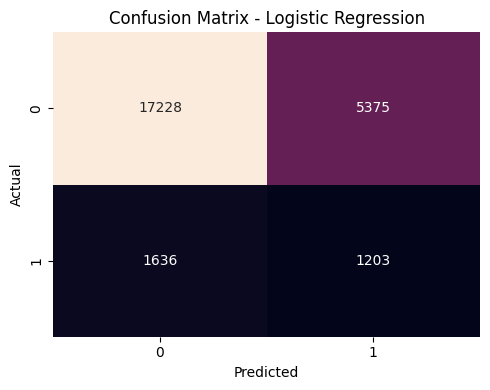

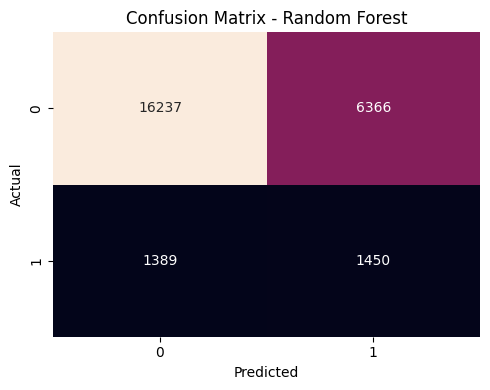

In [17]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

os.makedirs("outputs/figures", exist_ok=True)

def plot_cm(cm, title, outpath):
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cbar=False)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.savefig(outpath, dpi=300)
    plt.show()

plot_cm(np.array(lr_metrics["confusion_matrix"]), "Confusion Matrix - Logistic Regression", "outputs/figures/cm_lr.png")
plot_cm(np.array(rf_metrics["confusion_matrix"]), "Confusion Matrix - Random Forest", "outputs/figures/cm_rf.png")

**Generate ROC + PR curves**

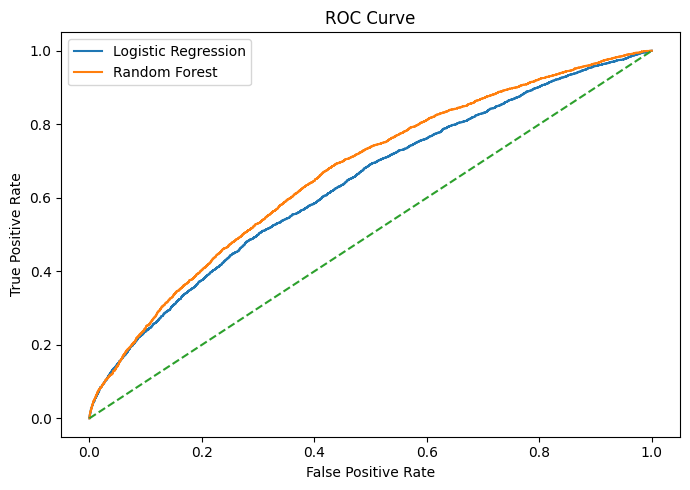

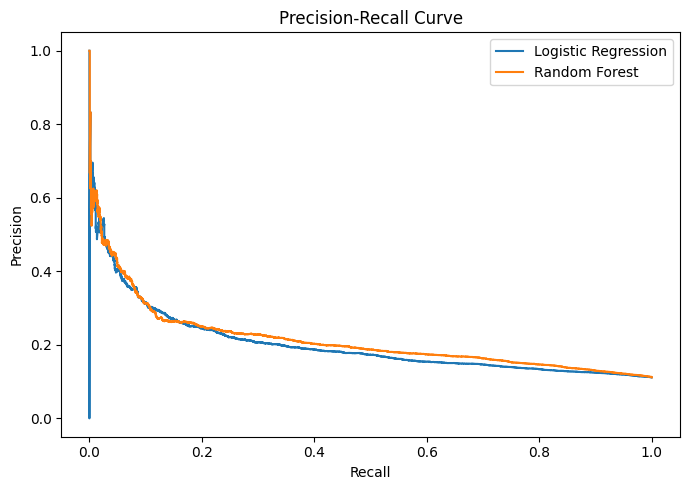

✅ Saved roc_curve.png and pr_curve.png


In [22]:
from sklearn.metrics import roc_curve, precision_recall_curve

# ROC
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_proba)

plt.figure(figsize=(7,5))
plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1],[0,1], linestyle="--")
plt.title("ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/figures/roc_curve.png", dpi=300)
plt.show()

# PR Curve
p_lr, r_lr, _ = precision_recall_curve(y_test, lr_proba)
p_rf, r_rf, _ = precision_recall_curve(y_test, rf_proba)

plt.figure(figsize=(7,5))
plt.plot(r_lr, p_lr, label="Logistic Regression")
plt.plot(r_rf, p_rf, label="Random Forest")
plt.title("Precision-Recall Curve")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.legend()
plt.tight_layout()
plt.savefig("outputs/figures/pr_curve.png", dpi=300)
plt.show()

print("✅ Saved roc_curve.png and pr_curve.png")

**Cluster analysis + save plot**

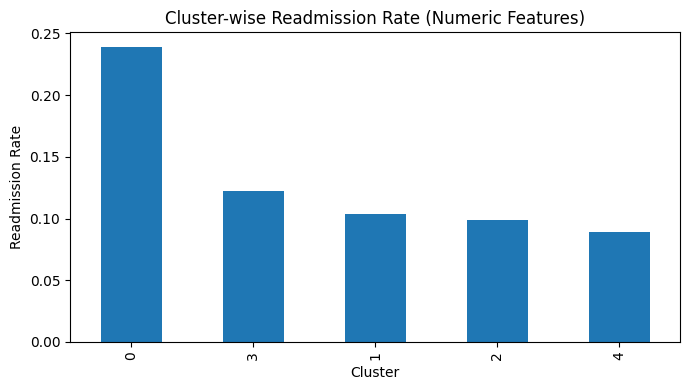

✅ Saved outputs/figures/cluster_risk.png


,label
cluster,
0,0.238994
3,0.122535
1,0.103308
2,0.098915
4,0.088958


In [25]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# ---------------- FAST CLUSTERING ----------------
# Use ONLY numeric columns for clustering (no one-hot explosion)
X_num = df[num_cols].copy()

# Impute + scale numeric only
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

X_num_imp = SimpleImputer(strategy="median").fit_transform(X_num)
X_num_scaled = StandardScaler().fit_transform(X_num_imp)

# (Optional) Use a sample to speed up further
# Clustering on 20k rows is enough for cohort patterns
SAMPLE_N = 20000
if X_num_scaled.shape[0] > SAMPLE_N:
    idx = np.random.RandomState(42).choice(X_num_scaled.shape[0], SAMPLE_N, replace=False)
    X_cluster = X_num_scaled[idx]
    y_cluster = y.values[idx]
else:
    X_cluster = X_num_scaled
    y_cluster = y.values

k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster)

tmp = pd.DataFrame({"cluster": clusters, "label": y_cluster})
cluster_rates = tmp.groupby("cluster")["label"].mean().sort_values(ascending=False)

plt.figure(figsize=(7,4))
cluster_rates.plot(kind="bar")
plt.title("Cluster-wise Readmission Rate (Numeric Features)")
plt.xlabel("Cluster")
plt.ylabel("Readmission Rate")
plt.tight_layout()
plt.savefig("outputs/figures/cluster_risk.png", dpi=300)
plt.show()

print("✅ Saved outputs/figures/cluster_risk.png")
cluster_rates

**K-Means cohort discovery**

In [27]:
from sklearn.cluster import KMeans

X_num = X[num_cols].copy()
X_num = X_num.apply(pd.to_numeric, errors="coerce")
X_num = X_num.fillna(X_num.median(numeric_only=True))

# scale numeric
X_scaled = (X_num - X_num.mean()) / (X_num.std() + 1e-9)

kmeans = KMeans(n_clusters=5, random_state=42, n_init="auto")
clusters = kmeans.fit_predict(X_scaled)

cohort = pd.DataFrame(X_scaled)
cohort["cluster"] = clusters
cohort["label"] = y.values

display(cohort.groupby("cluster")["label"].mean().sort_values(ascending=False))

,label
cluster,
0,0.249161
1,0.151338
3,0.116620
4,0.106998
2,0.077307


**Blockchain-style integrity anchoring**

In [28]:
import hashlib, json, time

def sha256_bytes(b: bytes) -> str:
    return hashlib.sha256(b).hexdigest()

def sha256_file(path: str) -> str:
    with open(path, "rb") as f:
        return sha256_bytes(f.read())

def sha256_json(obj) -> str:
    payload = json.dumps(obj, sort_keys=True, separators=(",", ":")).encode("utf-8")
    return sha256_bytes(payload)

os.makedirs("outputs", exist_ok=True)
ledger_path = "outputs/ledger.json"

# init ledger
if not os.path.exists(ledger_path):
    with open(ledger_path, "w") as f:
        json.dump({"entries": []}, f, indent=2)

dataset_hash = sha256_file(csv_path)

metrics_payload = {"lr": lr_metrics, "rf": rf_metrics}
metrics_hash = sha256_json(metrics_payload)

entry_1 = {"ts": time.time(), "artifact": "dataset_snapshot", "sha256": dataset_hash}
entry_2 = {"ts": time.time(), "artifact": "metrics_snapshot", "sha256": metrics_hash}

ledger = json.load(open(ledger_path))
ledger["entries"].extend([entry_1, entry_2])
json.dump(ledger, open(ledger_path, "w"), indent=2)

json.dump(metrics_payload, open("outputs/metrics.json", "w"), indent=2)
json.dump({"dataset_sha256": dataset_hash, "metrics_sha256": metrics_hash},
          open("outputs/model_hashes.json", "w"), indent=2)

print("✅ Saved:")
print("- outputs/metrics.json")
print("- outputs/model_hashes.json")
print("- outputs/ledger.json")
print("- outputs/figures/*.png")

✅ Saved:
- outputs/metrics.json
- outputs/model_hashes.json
- outputs/ledger.json
- outputs/figures/*.png


**Download entire project as one ZIP**

In [29]:
import os
import zipfile
from pathlib import Path
from google.colab import files

# Create a project folder
project_dir = Path("/content/readmission_project")
project_dir.mkdir(parents=True, exist_ok=True)

# Copy dataset
os.system("cp -r data readmission_project/")

# Copy outputs
os.system("cp -r outputs readmission_project/")

# Copy notebook itself
os.system("cp /content/*.ipynb readmission_project/")

# Create ZIP file
zip_path = "/content/readmission_project.zip"
with zipfile.ZipFile(zip_path, "w", zipfile.ZIP_DEFLATED) as z:
    for root, dirs, files_in_dir in os.walk(project_dir):
        for file in files_in_dir:
            full_path = os.path.join(root, file)
            relative_path = os.path.relpath(full_path, project_dir)
            z.write(full_path, relative_path)

print("✅ Created ZIP:", zip_path)

# Download
files.download(zip_path)

✅ Created ZIP: /content/readmission_project.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>